# Pacotes & Configurações:

## Para fazer com que o Jupyter Notebook exiba as figuras diretamente nas células:

In [1]:
%matplotlib inline

## Importação de pacotes nativos do python

In [2]:
from time import time

from os import path,remove

import pandas as pd

import numpy as np

from ipywidgets import interactive

import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from scipy.signal import butter, filtfilt

import imageio.v2 as imageio  # imageio.v2 evita warnings

## Importação de pacotes que necessitam de instalação

In [3]:
# segysak (https://trhallam.github.io/segysak/latest/)
# pip install segysak
from segysak.segy import get_segy_texthead, segy_header_scan, segy_header_scrape

# xarray (https://docs.xarray.dev/en/stable/)
# pip install xarray
import xarray as xr

# Cartopy (https://scitools.org.uk/cartopy/docs/latest/)
# pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes

# pyproj
# pip install pyproj
import pyproj

# Pacote principal 

# segysak 
- https://trhallam.github.io/segysak/latest/index.html
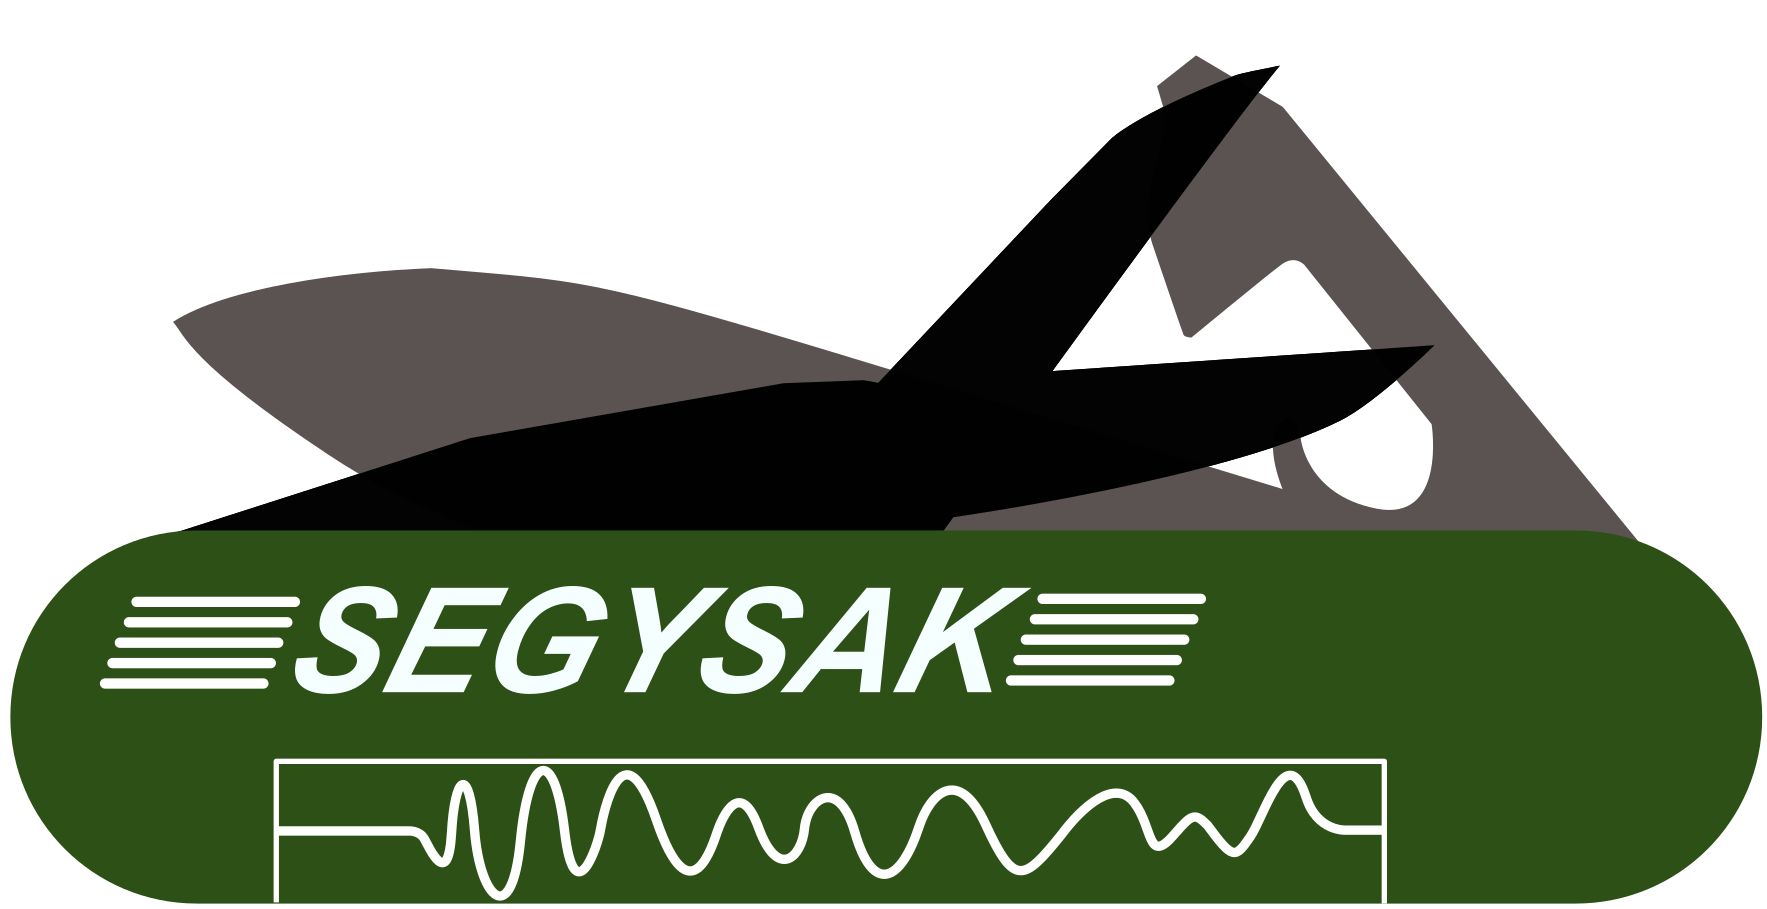

### Tutorial:
- https://trhallam.github.io/segysak/latest/tutorial.html

## Passos para a leitura do arquivo de sísmica 2D (SEGY):
**1. Checar se existe o arquivo:**

In [4]:
segy_file = "/media/enseadamartel/Expansion/dados_monitor1/estacao258_total.sgy"
print("Aquivo sísmica 2D:", segy_file,"\nExiste:",path.exists(segy_file))

Aquivo sísmica 2D: /media/enseadamartel/Expansion/dados_monitor1/estacao258_total.sgy 
Existe: True


**2. Ler o cabeçalho (header) e checar a localização dos bytes via segy_header_scan:**
- https://trhallam.github.io/segysak/latest/api/segy_inspecting.html#segysak.segy.segy_bin_scrape

In [5]:
scan = segy_header_scan(segy_file,max_traces_scan=200000)

with pd.option_context("display.max_rows", 100, "display.max_columns", 10):
    # drop byte locations where the mean is zero, these are likely empty.
    display(scan)

Processing Chunks:   0%|          | 0.00/2.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

,byte_loc,count,mean,std,min,25%,50%,75%,max
TRACE_SEQUENCE_LINE,1,200000.0,1.000005e+05,57735.171256,1.0,5.000075e+04,100000.5,1.500002e+05,200000.0
TRACE_SEQUENCE_FILE,5,200000.0,1.000000e+00,0.000000,1.0,1.000000e+00,1.0,1.000000e+00,1.0
FieldRecord,9,200000.0,2.180153e+02,126.146945,1.0,1.090000e+02,205.0,3.240000e+02,461.0
TraceNumber,13,200000.0,2.580000e+02,0.000000,258.0,2.580000e+02,258.0,2.580000e+02,258.0
EnergySourcePoint,17,200000.0,1.221633e+03,128.070239,1001.0,1.109000e+03,1224.0,1.333000e+03,1441.0
CDP,21,200000.0,4.200636e+05,35651.365908,358827.0,3.893438e+05,419770.5,4.509252e+05,483448.0
CDP_TRACE,25,200000.0,0.000000e+00,0.000000,0.0,0.000000e+00,0.0,0.000000e+00,0.0
TraceIdentificationCode,29,200000.0,1.000000e+00,0.000000,1.0,1.000000e+00,1.0,1.000000e+00,1.0
NSummedTraces,31,200000.0,1.000000e+00,0.000000,1.0,1.000000e+00,1.0,1.000000e+00,1.0
NStackedTraces,33,200000.0,1.000000e+00,0.000000,1.0,1.000000e+00,1.0,1.000000e+00,1.0


In [21]:
ds = xr.open_dataset(segy_file, dim_byte_fields={'cdp': 25})

Processing Chunks:   0%|          | 0.00/8.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/81.5k [00:00<?, ? traces/s]

ValueError: The selected dimensions results in multiple traces per dimension location, add additional dimensions or use trace numbering byte location to load as 2D.

**3. Acessar, armazenar e graficar os dados do cabeçalho (header) via segy_header_scrape:**
- https://trhallam.github.io/segysak/latest/api/segy_inspecting.html#segysak.segy.segy_header_scrape
- Transforma a saída dos dados em um objeto chamado **scrape**

In [6]:
scrape = segy_header_scrape(segy_file, partial_scan=None)

Processing Chunks:   0%|          | 0.00/8.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/81.5k [00:00<?, ? traces/s]

In [7]:
scrape.columns

Index(['TRACE_SEQUENCE_LINE', 'TRACE_SEQUENCE_FILE', 'FieldRecord',
       'TraceNumber', 'EnergySourcePoint', 'CDP', 'CDP_TRACE',
       'TraceIdentificationCode', 'NSummedTraces', 'NStackedTraces', 'DataUse',
       'offset', 'ReceiverGroupElevation', 'SourceSurfaceElevation',
       'SourceDepth', 'ReceiverDatumElevation', 'SourceDatumElevation',
       'SourceWaterDepth', 'GroupWaterDepth', 'ElevationScalar',
       'SourceGroupScalar', 'SourceX', 'SourceY', 'GroupX', 'GroupY',
       'CoordinateUnits', 'WeatheringVelocity', 'SubWeatheringVelocity',
       'SourceUpholeTime', 'GroupUpholeTime', 'SourceStaticCorrection',
       'GroupStaticCorrection', 'TotalStaticApplied', 'LagTimeA', 'LagTimeB',
       'DelayRecordingTime', 'MuteTimeStart', 'MuteTimeEND',
       'TRACE_SAMPLE_COUNT', 'TRACE_SAMPLE_INTERVAL', 'GainType',
       'InstrumentGainConstant', 'InstrumentInitialGain', 'Correlated',
       'SweepFrequencyStart', 'SweepFrequencyEnd', 'SweepLength', 'SweepType',
       'Swee

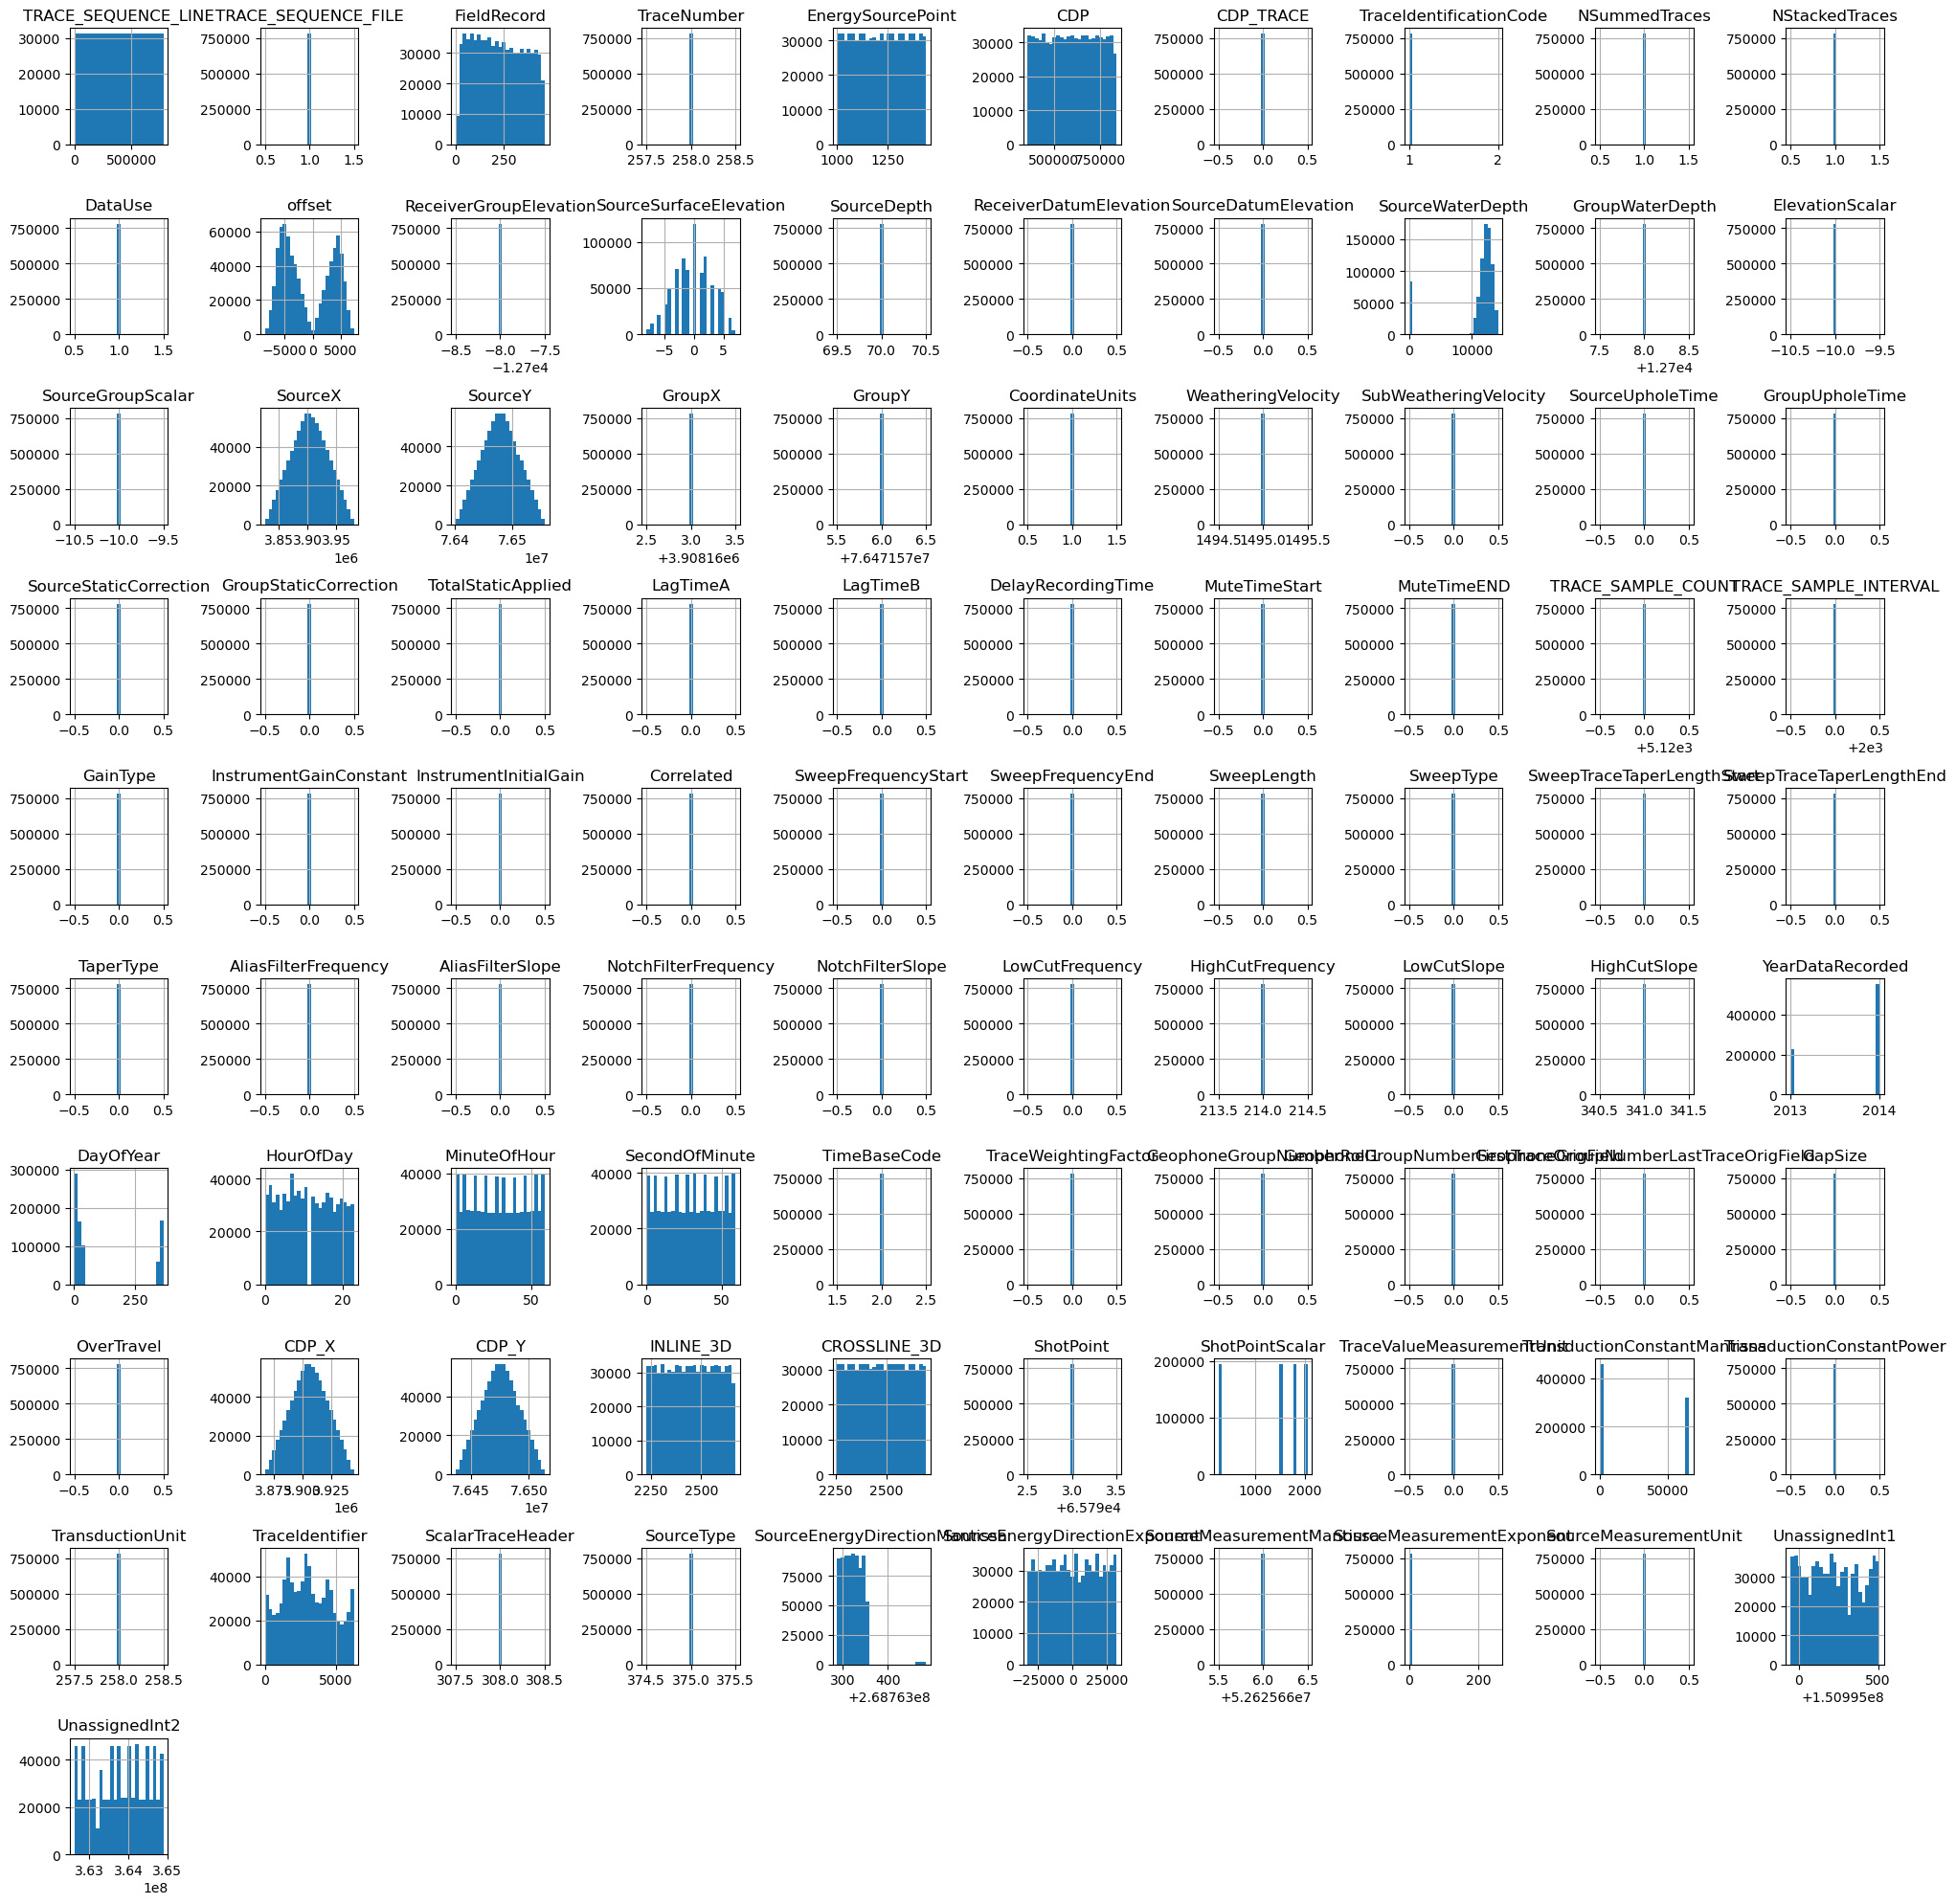

In [8]:
plot = scrape.hist(bins=25, figsize=(20, 20))
plt.tight_layout()
plt.show()

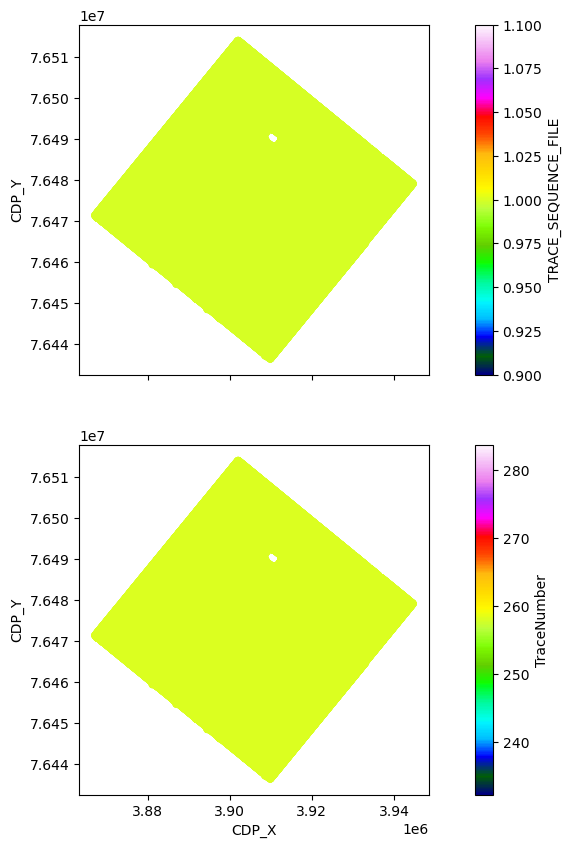

In [9]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 10), sharex=True, sharey=True)

scrape.plot(
    kind="scatter", x="CDP_X", y="CDP_Y", c="TRACE_SEQUENCE_FILE", ax=axs[0], cmap="gist_ncar"
)
scrape.plot(
    kind="scatter", x="CDP_X", y="CDP_Y", c="TraceNumber", ax=axs[1], cmap="gist_ncar"
)
for aa in axs:
    aa.set_aspect("equal", "box")
plt.show()

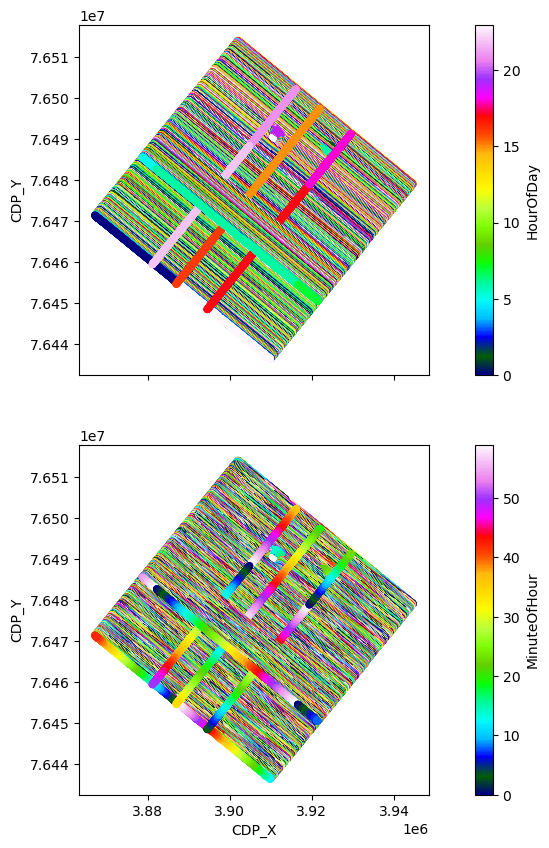

In [10]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 10), sharex=True, sharey=True)

scrape.plot(
    kind="scatter", x="CDP_X", y="CDP_Y", c="HourOfDay", ax=axs[0], cmap="gist_ncar"
)
scrape.plot(
    kind="scatter", x="CDP_X", y="CDP_Y", c="MinuteOfHour", ax=axs[1], cmap="gist_ncar"
)
for aa in axs:
    aa.set_aspect("equal", "box")
plt.show()

**4. Ler os dados SEG-Y via xarray open_dataset:**
- https://trhallam.github.io/segysak/latest/examples/example_segysak_segy_vectorisation.html
- https://docs.xarray.dev/en/stable/generated/xarray.open_dataset.html
- Usar o **TRACE_SEQUENCE_FILE (?CDP?)**
  -  Localização do byte:	5

In [18]:
ds = xr.open_dataset(segy_file, dim_byte_fields={'cdp': 13})

Processing Chunks:   0%|          | 0.00/8.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/100k [00:00<?, ? traces/s]

Reading header:   0%|          | 0.00/81.5k [00:00<?, ? traces/s]

ValueError: The selected dimensions results in multiple traces per dimension location, add additional dimensions or use trace numbering byte location to load as 2D.

In [12]:
ds.keys()

KeysView(<xarray.Dataset> Size: 1GB
Dimensions:  (cdp: 131978, samples: 2501)
Coordinates:
  * cdp      (cdp) int32 528kB 1 2 3 4 5 ... 131974 131975 131976 131977 131978
  * samples  (samples) float32 10kB 0.0 2.0 4.0 ... 4.996e+03 4.998e+03 5e+03
Data variables:
    data     (cdp, samples) float32 1GB ...
Attributes:
    seisnc:   {"coord_scalar": -10.0, "coord_scaled": false})

----

**5. Graficar os dados SEG-Y via xarray:**
- https://docs.xarray.dev/en/latest/user-guide/plotting.html

ou


- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html

In [13]:
tiro_1 = ds.isel(cdp=slice(75460, 75610))

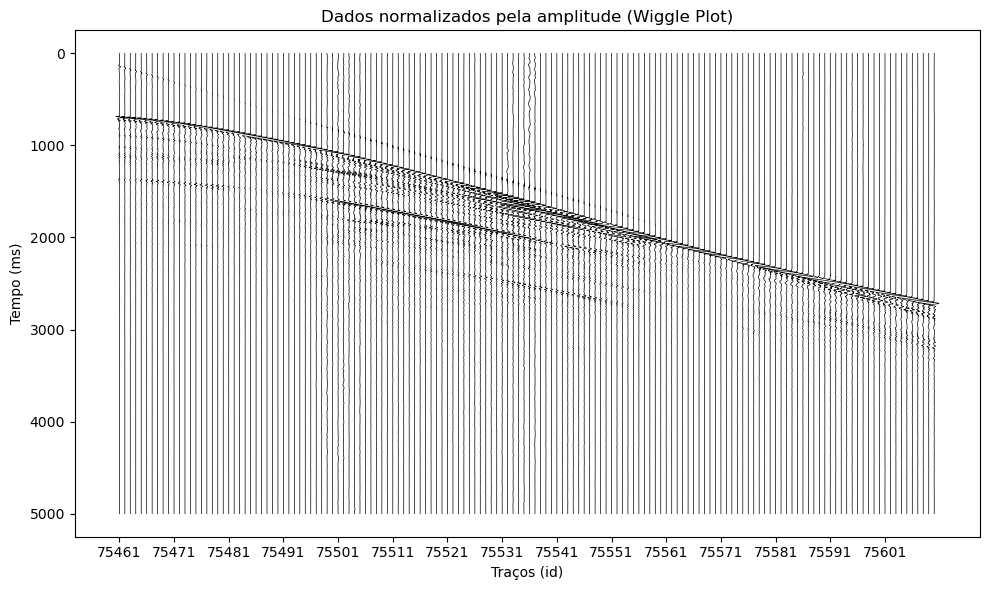

In [14]:
# Normalização dos dados 
normalized = tiro_1 / np.abs(tiro_1).max(dim='samples')

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each trace (wiggle plot style)
for i, cdp_val in enumerate(tiro_1.cdp.values):
    trace = normalized.sel(cdp=cdp_val)
    ax.plot(trace.data + i, tiro_1.samples, color='black', linewidth=0.5)

# Set Y-axis (samples)
ax.invert_yaxis()
ax.set_ylabel("Tempo (ms)")

# Set X-axis (cdp index)
ax.set_xlabel("Traços (id)")
ax.set_xticks(np.arange(0, len(tiro_1.cdp), 10))
ax.set_xticklabels(tiro_1.cdp.values[::10])

ax.set_title("Dados normalizados pela amplitude (Wiggle Plot)")
plt.tight_layout()
plt.show()

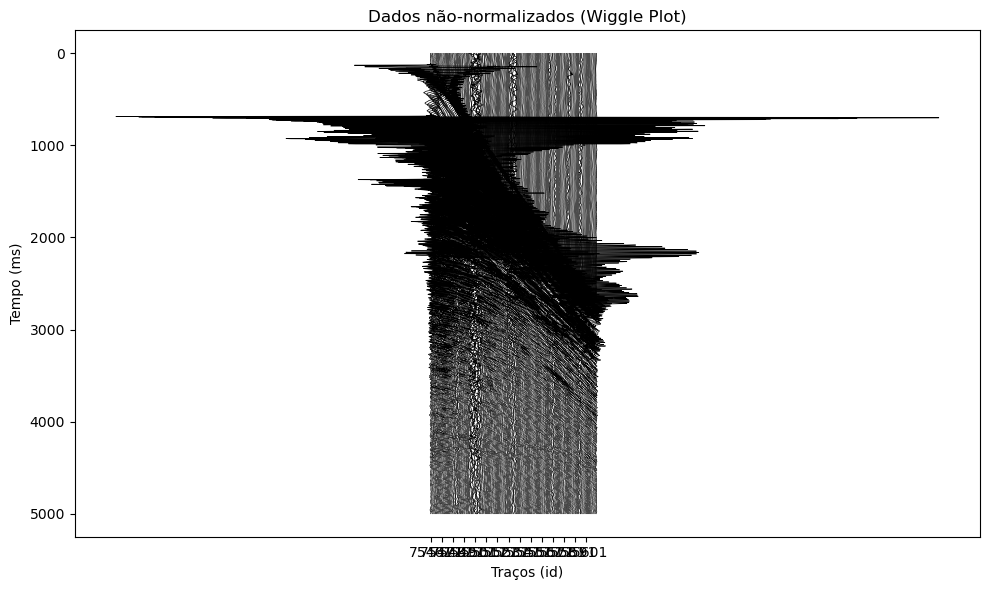

In [15]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each trace (wiggle plot style)
for i, cdp_val in enumerate(tiro_1.cdp.values):
    trace = tiro_1.sel(cdp=cdp_val)
    ax.plot(trace.data + i, tiro_1.samples, color='black', linewidth=0.5)

# Set Y-axis (samples)
ax.invert_yaxis()
ax.set_ylabel("Tempo (ms)")

# Set X-axis (cdp index)
ax.set_xlabel("Traços (id)")
ax.set_xticks(np.arange(0, len(tiro_1.cdp), 10))
ax.set_xticklabels(tiro_1.cdp.values[::10])
ax.set_aspect('auto')
ax.set_title("Dados não-normalizados (Wiggle Plot)")
plt.tight_layout()
plt.show()

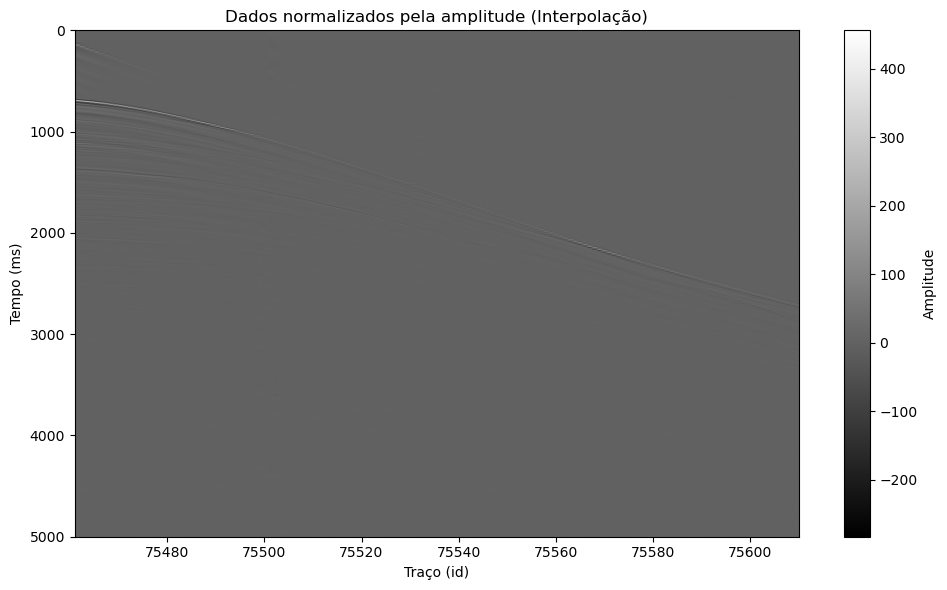

In [16]:
# Dados normalizados interpolados

amplitude = tiro_1.transpose('samples', 'cdp').data

# Criar figura
fig, ax = plt.subplots(figsize=(10, 6))

# Exibir imagem com imshow
im = ax.imshow(
    amplitude,                     # dados
    aspect='auto',                 # não distorce eixos
    cmap='gray',                   # colormap para estilo sísmico
    extent=[
        tiro_1.cdp.min(), tiro_1.cdp.max(), 
        tiro_1.samples.max(), tiro_1.samples.min()
    ]
)

# Ajuste de eixos
ax.set_xlabel("Traço (id)")
ax.set_ylabel("Tempo (ms)")
ax.set_title("Dados normalizados pela amplitude (Interpolação)")

plt.colorbar(im, ax=ax, label='Amplitude')
plt.tight_layout()
plt.show()

----

**6. Filtragem dos dados SEG-Y via xarray.apply_ufunc:**
- https://docs.xarray.dev/en/stable/generated/xarray.apply_ufunc.html

In [17]:
def bandpass_filter(trace, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, trace)

In [18]:
def filter_dataset_bandpass_ufunc(ds, var="data", fs=250, lowcut=1, highcut=20, order=4):
    """
    Aplica filtro bandpass à variável `var` de um xarray.Dataset 3D (iline, xline, samples)
    sem remover dimensões. Retorna novo Dataset com variável filtrada.
    """
    da = ds[var]

    # Aplica o filtro ao longo da dimensão "samples"
    da_filtered = xr.apply_ufunc(
        bandpass_filter,
        da,
        input_core_dims=[["samples"]],
        output_core_dims=[["samples"]],
        kwargs={"fs": fs, "lowcut": lowcut, "highcut": highcut, "order": order},
        vectorize=True,
        dask="allowed",
        output_dtypes=[da.dtype]
    )

    # Cria cópia do Dataset com a variável filtrada
    ds_filtered = ds.copy()
    ds_filtered[var] = da_filtered

    return ds_filtered

In [22]:
def f(lf, hf,t1,t2):
    
    tiro_1_filtered = filter_dataset_bandpass_ufunc(tiro_1, var="data", fs=250, lowcut=lf, highcut=hf)

    # Create figure and axis
    fig, (ax1,ax2) = plt.subplots(nrows= 1,ncols=2,figsize=(15, 5))
    
    # Normalização dos dados 
    normalized = tiro_1 / np.abs(tiro_1).max(dim='samples')
    
    # Plot each trace (wiggle plot style)
    for i, cdp_val in enumerate(tiro_1.cdp.values):
        trace = normalized.sel(cdp=cdp_val)
        ax1.plot(trace.data + i, tiro_1.samples, color='black', linewidth=0.5)
    
    # Set Y-axis (samples)
    ax1.invert_yaxis()
    ax1.set_ylabel("Tempo (ms)")
    ax1.set_ylim(t2,t1)
    
    # Set X-axis (cdp index)
    ax1.set_xlabel("Traços (id)")
    ax1.set_xticks(np.arange(0, len(tiro_1.cdp), 20))
    ax1.set_xticklabels(tiro_1.cdp.values[::20])
    
    ax1.set_title("Dados normalizados")
    
    # ----------------------------------------------------------------------------
    
    # Normalização dos dados 
    normalized = tiro_1_filtered / np.abs(tiro_1_filtered).max(dim='samples')
    
    # Plot each trace (wiggle plot style)
    for i, cdp_val in enumerate(tiro_1_filtered.cdp.values):
        trace = normalized.sel(cdp=cdp_val)
        ax2.plot(trace.data + i, tiro_1_filtered.samples, color='black', linewidth=0.5)
    
    # Set Y-axis (samples)
    ax2.invert_yaxis()
    ax2.set_ylim(t2,t1)
    
    # Set X-axis (cdp index)
    ax2.set_xlabel("Traços (id)")
    ax2.set_xticks(np.arange(0, len(tiro_1_filtered.cdp), 20))
    ax2.set_xticklabels(tiro_1_filtered.cdp.values[::20])
    
    ax2.set_title("Dados normalizados filtrados")
    
    
    plt.tight_layout()
    plt.show()
    
interactive_plot = interactive(f, lf=(5, 100), hf=(10, 124, 5),t2=(0,5000,100),t1=(0,5000,100))
output = interactive_plot.children[-1]
output.layout.height = '700px'
interactive_plot

interactive(children=(IntSlider(value=52, description='lf', min=5), IntSlider(value=65, description='hf', max=…

In [20]:
def f(lf, hf,t1,t2,apmlim):
    trace_val = 1
    trace = tiro_1.isel(cdp=trace_val)

    tiro_1_filtered = filter_dataset_bandpass_ufunc(tiro_1, var="data", fs=250, lowcut=lf, highcut=hf)

    trace_filtered = tiro_1_filtered.isel(cdp=trace_val)
    
    # Criando figura and eixos
    fig, (ax1,ax2,ax3) = plt.subplots(nrows= 1,ncols=3,figsize=(10, 6))
     
    # ===================================================
    # Traço bruto
    
    ax1.plot(trace.data, trace.samples, color='black', linewidth=0.5)
    
    # Set Y-axis (samples)
    ax1.invert_yaxis()
    ax1.set_ylim(t2,t1)
    ax1.set_xlim(-apmlim,apmlim)
    
    # Set X-axis (cdp index)
    ax1.set_xlabel("Amp ()")
    
    ax1.set_title('Bruto')
    
    # ===================================================
    # Traço normalizado
    
    ax2.plot(trace_filtered.data, trace_filtered.samples, color='black', linewidth=0.5)
    
    # Set Y-axis (samples)
    ax2.invert_yaxis()
    ax2.set_ylim(t2,t1)
    
    # Set X-axis (cdp index)
    ax2.set_xlabel("Amp ()")
    
    ax2.set_title('Filtrado - bp('+str(lf)+'-'+str(hf)+'Hz)')
    
    # ===================================================
    # Diferença entre os traços
    trace_diff = trace-trace_filtered
    
    ax3.plot(trace_diff.data, trace_diff.samples, color='black', linewidth=0.5)
    
    # Set Y-axis (samples)
    ax3.invert_yaxis()
    ax3.set_ylim(t2,t1)
    ax3.set_xlim(-apmlim,apmlim)
    
    # Set X-axis (cdp index)
    ax3.set_xlabel("Amp ()")
    
    ax3.set_title('Diferença')
    
    fig.suptitle('Traço - id: '+str(trace_val))
    plt.show()
    
interactive_plot = interactive(f, lf=(1, 100), hf=(1, 124, 5),t2=(0,5000,100),t1=(0,5000,100),apmlim=(10,300,10))
output = interactive_plot.children[-1]
output.layout.height = '700px'
interactive_plot

interactive(children=(IntSlider(value=50, description='lf', min=1), IntSlider(value=61, description='hf', max=…

In [85]:
def f_frame(lf, hf,t1,t2):
    
    tiro_1_filtered = filter_dataset_bandpass_ufunc(tiro_1, var="data", fs=250, lowcut=lf, highcut=hf)

    # Create figure and axis
    fig, (ax1,ax2) = plt.subplots(nrows= 1,ncols=2,figsize=(15, 5))
    
    # Normalização dos dados 
    normalized = tiro_1 / np.abs(tiro_1).max(dim='samples')
    
    # Plot each trace (wiggle plot style)
    for i, cdp_val in enumerate(tiro_1.cdp.values):
        trace = normalized.sel(cdp=cdp_val)
        ax1.plot(trace.data + i, tiro_1.samples, color='black', linewidth=0.5)
    
    # Set Y-axis (samples)
    ax1.invert_yaxis()
    ax1.set_ylabel("Tempo (ms)")
    ax1.set_ylim(t2,t1)
    
    # Set X-axis (cdp index)
    ax1.set_xlabel("Traços (id)")
    ax1.set_xticks(np.arange(0, len(tiro_1.cdp), 20))
    ax1.set_xticklabels(tiro_1.cdp.values[::20])
    
    ax1.set_title("Raw")
    
    # ----------------------------------------------------------------------------
    
    # Normalização dos dados 
    normalized = tiro_1_filtered / np.abs(tiro_1_filtered).max(dim='samples')
    
    # Plot each trace (wiggle plot style)
    for i, cdp_val in enumerate(tiro_1_filtered.cdp.values):
        trace = normalized.sel(cdp=cdp_val)
        ax2.plot(trace.data + i, tiro_1_filtered.samples, color='black', linewidth=0.5)
    
    # Set Y-axis (samples)
    ax2.invert_yaxis()
    ax2.set_ylim(t2,t1)
    
    # Set X-axis (cdp index)
    ax2.set_xlabel("Traços (id)")
    ax2.set_xticks(np.arange(0, len(tiro_1_filtered.cdp), 20))
    ax2.set_xticklabels(tiro_1_filtered.cdp.values[::20])
    
    ax2.set_title("Filtered")
    
    
    plt.tight_layout()

    fig.suptitle(f"bp = ({lf}-{hf} Hz)",fontsize=20)
    filename = '/home/enseadamartel/diogogit/OS2_codes/OS2_codes/seismic_inversion/Real_data/bloco_2D/frames/'+f"frame_lf{lf}_hf{hf}_t1{t1}_t2{t2}.png"
    
    plt.savefig(filename)
    #plt.close(fig)  

    return filename


In [86]:
pwd

'/home/enseadamartel/diogogit/OS2_codes/OS2_codes/seismic_inversion/Real_data/bloco_2D'

In [93]:
frames = []

for lf in range(1, 101, 1):
    hf = lf + 20
    t1 = 0
    t2 = 5000
    filename = f_frame(lf, hf, t1, t2)
    frames.append(filename)

# Filtra arquivos válidos
frames = [f for f in frames if f is not None and path.exists(f)]

# Gera o GIF
import imageio.v2 as imageio

with imageio.get_writer('/home/enseadamartel/diogogit/OS2_codes/OS2_codes/seismic_inversion/Real_data/bloco_2D/output.gif', mode='I', duration=0.1, loop=0) as writer:
    for frame in frames:
        image = imageio.imread(frame)
        writer.append_data(image)

# Limpa arquivos temporários
for frame in frames:
    remove(frame)